## Section 1: EDA and pre-processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv(r'bank-full-updated.csv')
print("Shape:", df.shape)
df.head()

Shape: (45211, 18)


,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [2]:
df = df.drop(columns=['ID']) # Drop ID column

# Basic info
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nDuplicates:", df.duplicated().sum())

# Check 'unknown' counts in categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f"  {col}: {unk} unknowns ({unk/len(df)*100:.1f}%)")

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object

Missing values:
 0

Duplicates: 0
  job: 288 unknowns (0.6%)
  education: 1857 unknowns (4.1%)
  contact: 13020 unknowns (28.8%)
  poutcome: 36959 unknowns (81.7%)


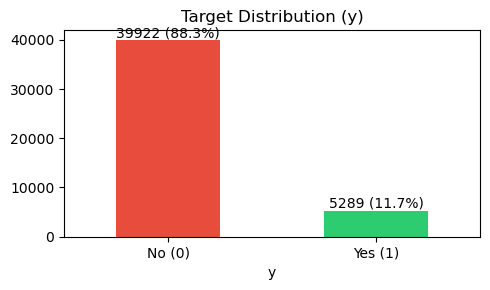

Class imbalance ratio: 7.5:1


In [3]:
# Target distribution
fig, ax = plt.subplots(figsize=(5, 3))
df['y'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Target Distribution (y)')
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
print(f"Class imbalance ratio: {df['y'].value_counts()[0] / df['y'].value_counts()[1]:.1f}:1")

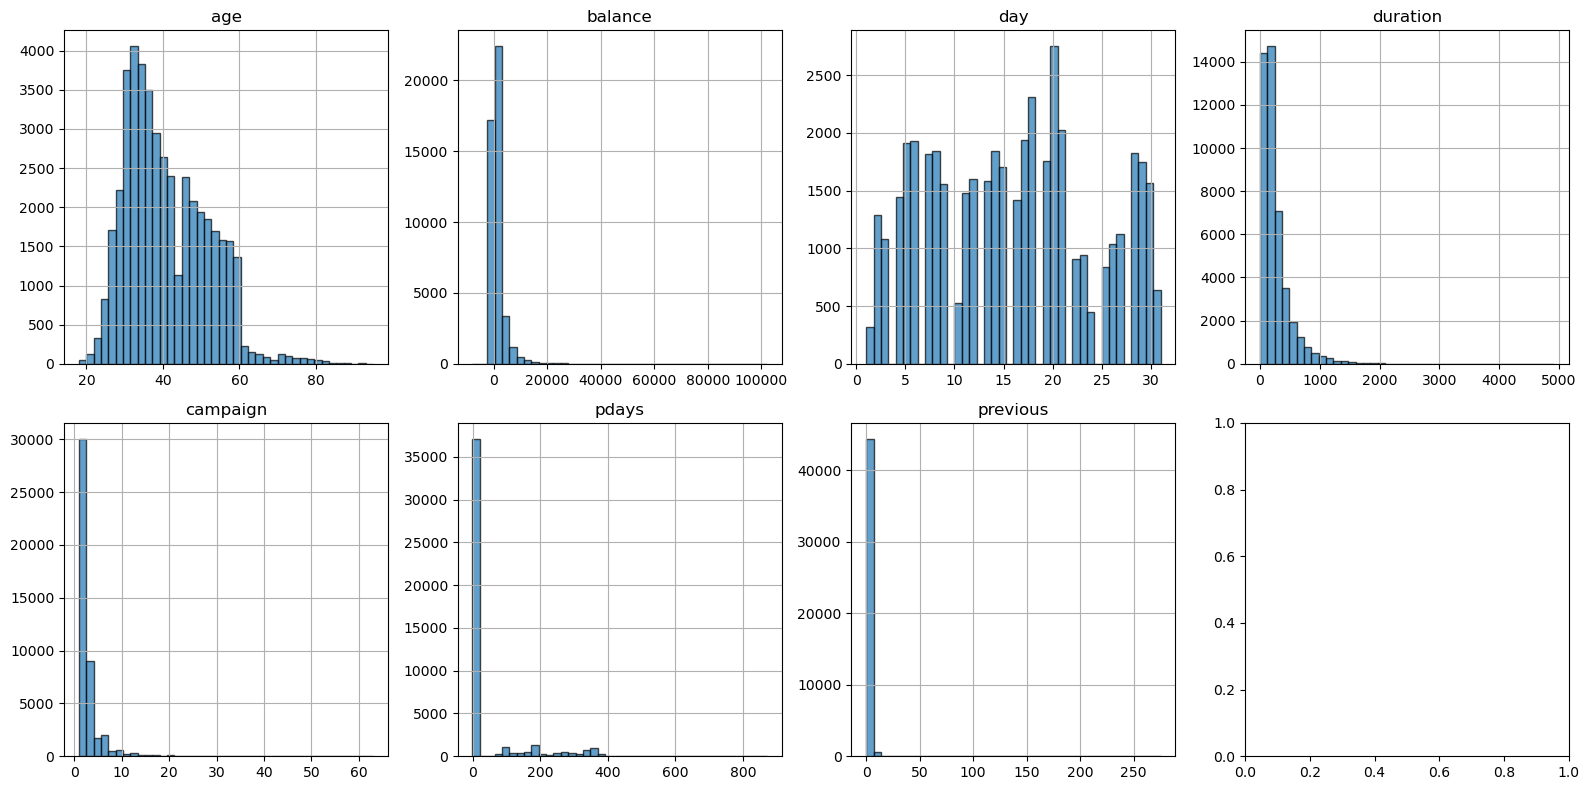

In [4]:
# Numeric feature distributions
num_cols = df.select_dtypes(include=np.number).columns.drop('y').tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    df[col].hist(bins=40, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col)
plt.tight_layout()
plt.show()

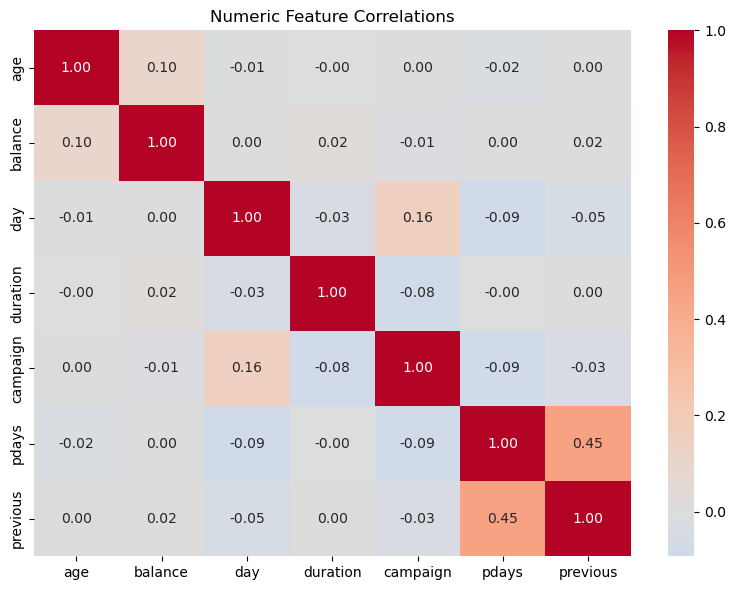

In [5]:
# Correlation heatmap (numeric features)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

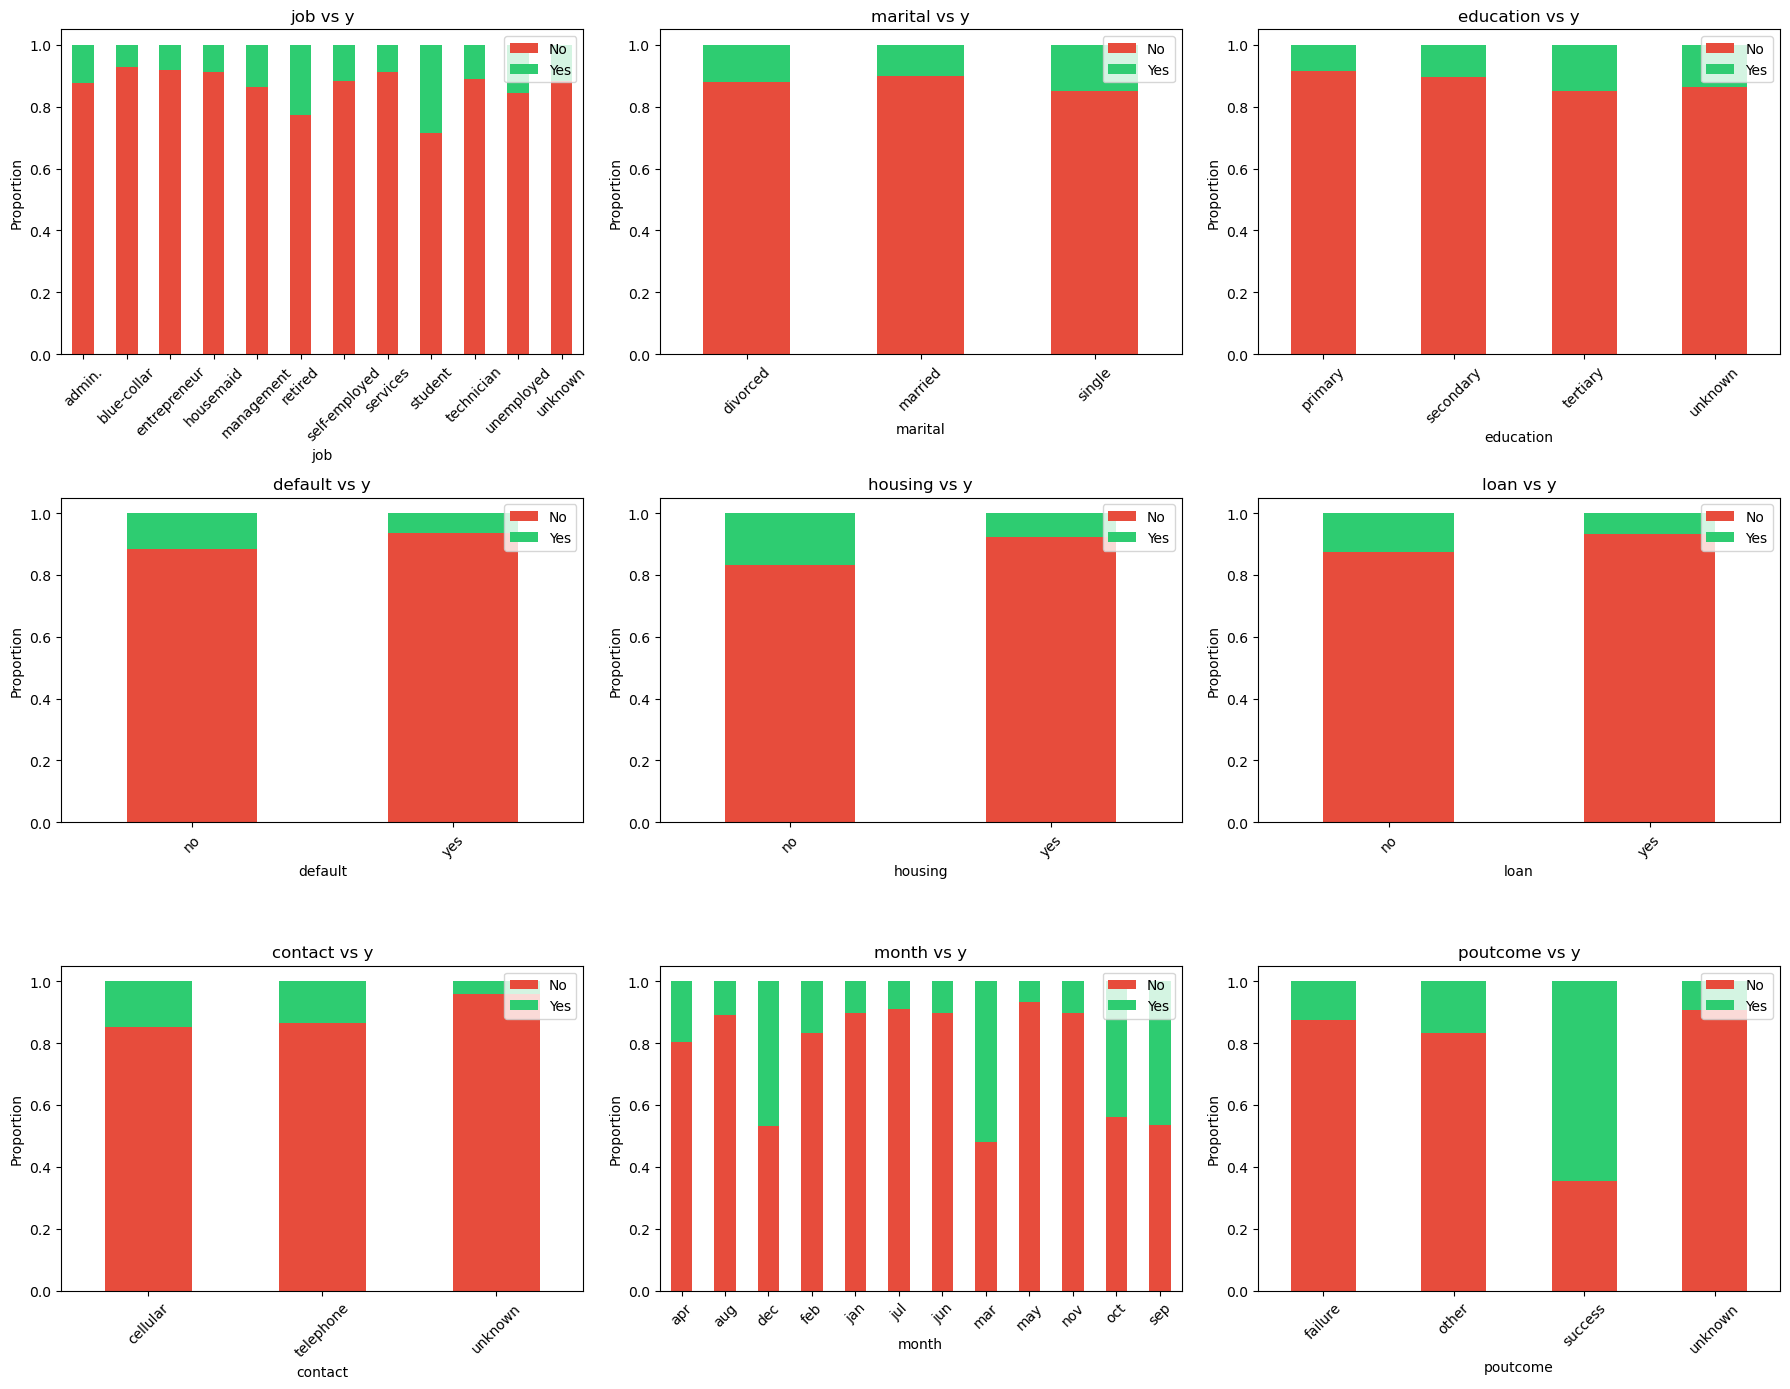

In [6]:
# Categorical features vs target
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for i, col in enumerate(cat_cols):
    ax = axes[i // 3][i % 3]
    ct = pd.crosstab(df[col], df['y'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{col} vs y')
    ax.set_ylabel('Proportion')
    ax.legend(['No', 'Yes'], loc='upper right')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# pdays distribution: Checking for sentinel values
print("pdays value counts (top 5):")
print(df['pdays'].value_counts().head())
print(f"\npdays == -1: {(df['pdays'] == -1).sum()} ({(df['pdays'] == -1).mean()*100:.1f}%)")

pdays value counts (top 5):
pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
Name: count, dtype: int64

pdays == -1: 36954 (81.7%)


## Section 1.1: Common code for pre-processing


In [8]:
# Feature engineering: flag for previously contacted
df['was_previously_contacted'] = (df['pdays'] != -1).astype(int)

# Group features into categorical and numerical lists for easier preprocessing
pre_call_cat = ['job', 'marital', 'education', 'default', 'housing',
                'loan', 'contact', 'month', 'poutcome']
pre_call_num = ['age', 'balance', 'day', 'campaign', 'pdays',
                'previous', 'was_previously_contacted']

print("Categorical features:", pre_call_cat)
print("Numeric features:", pre_call_num)
print(f"\nEngineered feature: was_previously_contacted (1 = {df['was_previously_contacted'].sum()} rows)")

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numeric features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_previously_contacted']

Engineered feature: was_previously_contacted (1 = 8257 rows)


## Section 1.2: One-Hot Encoding with StandardScaler
My first choice was One-Hot Encoding using StandardScaler. In this case, one-hot encoding makes sense because most of our categorical features, such as job kind and contact method, don't have a natural order. A "technician" is not "more" or "less" than a "manager." StandardScaler is my favorite way to normalize data because it handles outliers better than min-max scaling. This is important because the balance values can be quite high (up to ~100k) and the campaign counts can be very low.

In [9]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

preprocessor_ohe = ColumnTransformer([
    ('num', StandardScaler(), pre_call_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='infrequent_if_exist'), pre_call_cat)
])

pipe_ohe = Pipeline([
    ('preprocessor', preprocessor_ohe),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_pre = df[pre_call_num + pre_call_cat]
y_pre = df['y']

print("=== Approach 1: One-Hot Encoding + StandardScaler ===")
for metric in ['f1', 'roc_auc', 'accuracy']:
    scores = cross_val_score(pipe_ohe, X_pre, y_pre, cv=cv, scoring=metric)
    print(f"  {metric.upper()}: {scores.mean():.4f} (+/- {scores.std():.4f})")

preprocessor_ohe.fit(X_pre)
print(f"  Feature dimensions: {preprocessor_ohe.transform(X_pre).shape[1]}")

=== Approach 1: One-Hot Encoding + StandardScaler ===
  F1: 0.3756 (+/- 0.0045)
  ROC_AUC: 0.7664 (+/- 0.0081)
  ACCURACY: 0.7577 (+/- 0.0031)
  Feature dimensions: 42


## Section 1.3: Ordinal Encoding with MinMaxScaler
On my second method, i used Ordinal Encoding with MinMaxScaler. The key benefit here is feature space efficiency; instead of 42 features from one-hot encoding, we only obtain 16. I have applied a meaningful order to education(primary→secondary→tertiary), but the other category factors just get random numbers. MinMaxScaler limits everything to a range of 0 to 1. This could be useful later on if we were useing tree-based models or neural networks.

In [10]:
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

edu_order = [['primary', 'secondary', 'tertiary', 'unknown']]
other_cat = ['job', 'marital', 'default', 'housing', 'loan',
             'contact', 'month', 'poutcome']

preprocessor_ord = ColumnTransformer([
    ('num', MinMaxScaler(), pre_call_num),
    ('edu', OrdinalEncoder(categories=edu_order,
                           handle_unknown='use_encoded_value', unknown_value=-1), ['education']),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), other_cat)
])

pipe_ord = Pipeline([
    ('preprocessor', preprocessor_ord),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

print("=== Approach 2: Ordinal Encoding + MinMaxScaler ===")
for metric in ['f1', 'roc_auc', 'accuracy']:
    scores = cross_val_score(pipe_ord, X_pre, y_pre, cv=cv, scoring=metric)
    print(f"  {metric.upper()}: {scores.mean():.4f} (+/- {scores.std():.4f})")

preprocessor_ord.fit(X_pre)
print(f"  Feature dimensions: {preprocessor_ord.transform(X_pre).shape[1]}")

=== Approach 2: Ordinal Encoding + MinMaxScaler ===
  F1: 0.3270 (+/- 0.0071)
  ROC_AUC: 0.7347 (+/- 0.0112)
  ACCURACY: 0.6882 (+/- 0.0036)
  Feature dimensions: 16


## Section 1.4: Selection of Final Approach
Looking at the results, Approach 1 clearly wins across the board: F1 is 0.376 vs 0.327, AUC is 0.766 vs 0.735, and accuracy is 0.758 vs 0.688. The problem with ordinal encoding is that it creates fake relationships in the data, Here, the model starts thinking that job='manager' (encoded as 5) is somehow 'bigger' than job='technician' (encoded as 2), which doesn't make sense. Yes, one-hot encoding gives us more features, but with 45,000+ data points, that's not a problem. StandardScaler also handles our outliers better.So, I'm going with Approach 1 for everything that follows.

*****
## Section 2: Clustering

## Section 2.1: Data Preparation for Clustering


In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Selecting only the features relevant to the pre-call stage for our analysis
X_cluster = df[pre_call_num + pre_call_cat]

# Apply OHE with StandardScaler
cluster_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), pre_call_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='infrequent_if_exist'), pre_call_cat)
])

X_cluster_scaled = cluster_preprocessor.fit_transform(X_cluster)
print(f"Clustering input shape: {X_cluster_scaled.shape}")

Clustering input shape: (45211, 42)


## Section 2.2: K-Means
I'm starting with K-Means clustering because it's straightforward and quick, which is important when you have 45,000 data points. It works well here since I've already made sure that all of my one-hot encoded features are on the same scale. I'm going to utilize the elbow approach and silhouette scores to find the best amount of clusters. This means I'm going to seek for the point at which adding additional clusters stops helping us much.

  k=2: Silhouette=0.3413, Inertia=366179
  k=3: Silhouette=0.1335, Inertia=337099
  k=4: Silhouette=0.1419, Inertia=312789
  k=5: Silhouette=0.1422, Inertia=292460
  k=6: Silhouette=0.1342, Inertia=274429
  k=7: Silhouette=0.1405, Inertia=262962
  k=8: Silhouette=0.1175, Inertia=252620
  k=9: Silhouette=0.1251, Inertia=241268
  k=10: Silhouette=0.1198, Inertia=235713


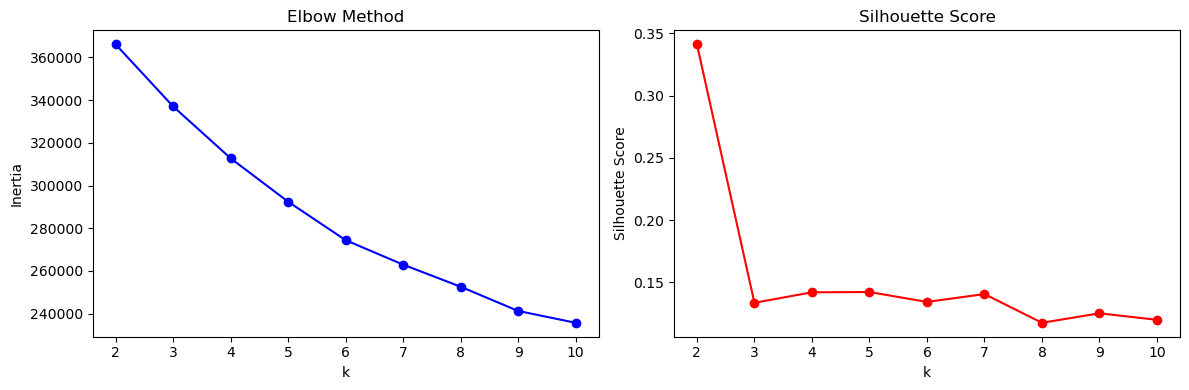

In [12]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Elbow method with silhouette scores
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    # setting n_init=10 and random_state for consistency
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    
    inertias.append(km.inertia_)
    score = silhouette_score(X_cluster_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)
    print(f"  k={k}: Silhouette={sil_scores[-1]:.4f}, Inertia={inertias[-1]:.0f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k'); 
axes[0].set_ylabel('Inertia'); 
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('k'); 
axes[1].set_ylabel('Silhouette Score'); 
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()


K-Means (k=3) — Silhouette: 0.1335

Cluster sizes:
0     8250
1    18593
2    18368
Name: count, dtype: int64

Subscription rate by cluster:
          No    Yes
row_0              
0      0.769  0.231
1      0.900  0.100
2      0.917  0.083


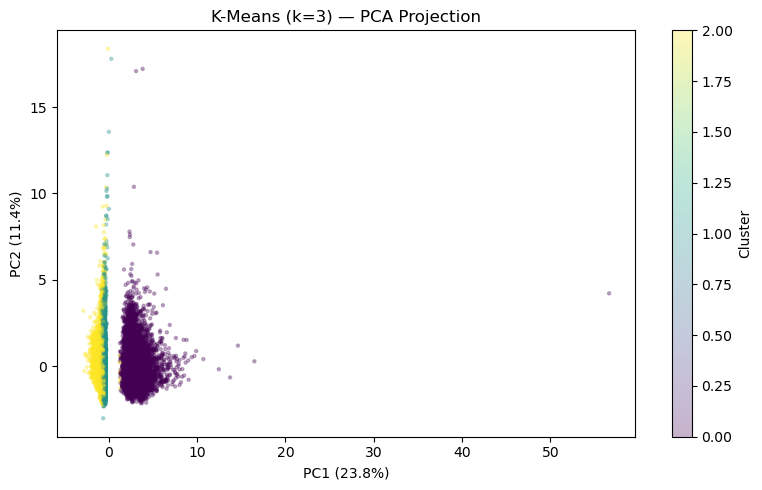

In [13]:
# Fit final K-Means with best k
best_k_km = 3
km_final = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_cluster_scaled)

print(f"\nK-Means (k={best_k_km}) — Silhouette: {silhouette_score(X_cluster_scaled, km_labels, sample_size=5000, random_state=42):.4f}")
print("\nCluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index())

# Subscription rate per cluster
km_crosstab = pd.crosstab(km_labels, df['y'], normalize='index')
km_crosstab.columns = ['No', 'Yes']
print("\nSubscription rate by cluster:")
print(km_crosstab.round(3))

# PCA visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'K-Means (k={best_k_km}) — PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## Section 2.3: Gaussian Mixture Model
My second method is a Gaussian Mixture Model (GMM). The main distinction between GMM and K-Means is that GMM allows "soft" cluster assignments. This means that a client can be part of more than one cluster instead of being pushed into just one. This makes sense for customer segmentation, as human behavior rarely fits into rigid, mutually exclusive categories. K-Means only works with spherical clusters, however GMM can work with clusters of all shapes and sizes. I'll use BIC (Bayesian Information Criterion) to choose the number of clusters. This will help me find the best fit while keeping the model simple.

  k=2: BIC=-2584543
  k=3: BIC=-4376149
  k=4: BIC=-5746788
  k=5: BIC=-6651908
  k=6: BIC=-7398918
  k=7: BIC=-8132262
  k=8: BIC=-8237282
  k=9: BIC=-8677445
  k=10: BIC=-8938671


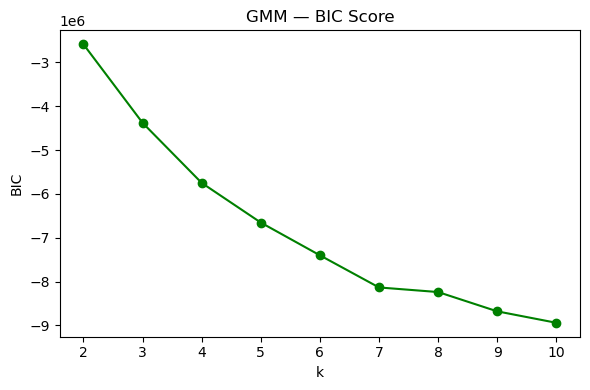

In [14]:
from sklearn.mixture import GaussianMixture

# BIC search
bics = []
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=3)
    gmm.fit(X_cluster_scaled)
    bics.append(gmm.bic(X_cluster_scaled))
    print(f"  k={k}: BIC={bics[-1]:.0f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(K_range, bics, 'go-')
ax.set_xlabel('k'); ax.set_ylabel('BIC'); ax.set_title('GMM — BIC Score')
plt.tight_layout()
plt.show()

Best k by BIC: 10
GMM (k=10) — Silhouette: 0.0228

Cluster sizes:
0     2940
1     1304
2    17230
3     1399
4     6972
5     5082
6     2564
7     4514
8      756
9     2450
Name: count, dtype: int64

Subscription rate by cluster:
          No    Yes
row_0              
0      0.899  0.101
1      0.649  0.351
2      0.926  0.074
3      0.730  0.270
4      0.935  0.065
5      0.892  0.108
6      0.897  0.103
7      0.841  0.159
8      0.772  0.228
9      0.701  0.299


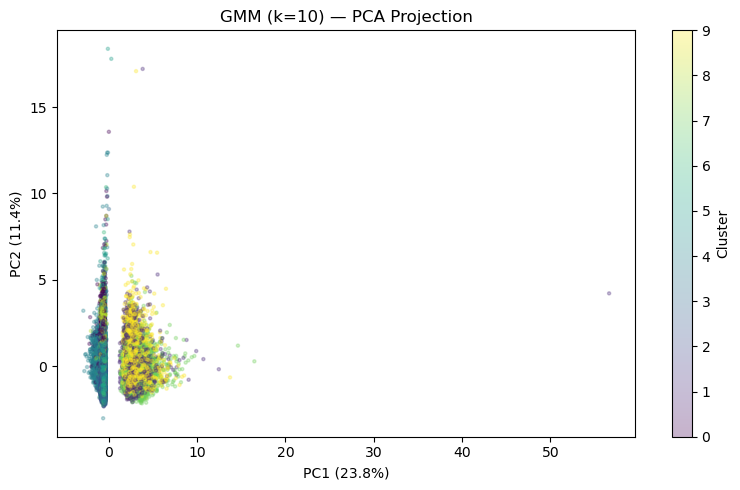

In [15]:
# Fit GMM with best k by BIC
best_k_gmm = K_range[np.argmin(bics)]
print(f"Best k by BIC: {best_k_gmm}")

gmm_final = GaussianMixture(n_components=best_k_gmm, random_state=42, n_init=3)
gmm_labels = gmm_final.fit_predict(X_cluster_scaled)

sil_gmm = silhouette_score(X_cluster_scaled, gmm_labels, sample_size=5000, random_state=42)
print(f"GMM (k={best_k_gmm}) — Silhouette: {sil_gmm:.4f}")
print("\nCluster sizes:")
print(pd.Series(gmm_labels).value_counts().sort_index())

gmm_crosstab = pd.crosstab(gmm_labels, df['y'], normalize='index')
gmm_crosstab.columns = ['No', 'Yes']
print("\nSubscription rate by cluster:")
print(gmm_crosstab.round(3))

# PCA visualisation
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'GMM (k={best_k_gmm}) — PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## Section 2.4: Selection of Final Approach
I finally chose K-Means with 3 clusters as it offered the best balance of statistical stability. 
While, k=2 have achieved the highest silhouette score of 0.341, k=3 was chosen based on the elbow method (clear inertia bend at k=3) and because three segments provide richer business insight than a binary split. The profile score for K-Means (k=3) was 0.134, while the score for GMM was 0.023. GMM's BIC continuously decreased to k=10 without reaching to a minimum, suggesting overfitting to the high-dimensional covariance structure rather than identifying natural groupings. The PCA projections confirm that, K-Means shows visible cluster separation, while GMM's 10 clusters overlap heavily. It's important to note that K-Means showed different subscription rates for each segment (23.1%, 10.0%, and 8.3%), showing a small, high-value group (Cluster 0) and two larger groups with different tendencies. This is a useful way to divide people for focused marketing. The cluster labels are integrated as an engineered feature for subsequent modelling.These cluster labels then become a feature I can use in my regression and classification models later.

In [16]:
# Adding K-Means cluster labels to the dataframe
df['cluster'] = km_labels
print("Cluster label added to dataframe.")
print(df[['cluster', 'y']].groupby('cluster').agg(['count', 'mean']).round(3))

Cluster label added to dataframe.
             y       
         count   mean
cluster              
0         8250  0.231
1        18593  0.100
2        18368  0.083



## Section 3: Regression

## Section 3.1: Regression Pipeline Setup


In [17]:
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

reg_num = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous',
           'was_previously_contacted', 'cluster']
reg_cat = ['job', 'marital', 'education', 'default', 'housing',
           'loan', 'contact', 'month', 'poutcome']

X_reg = df[reg_num + reg_cat]
y_reg = df['duration']

reg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), reg_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='infrequent_if_exist'), reg_cat)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Regression target (duration): mean={y_reg.mean():.1f}, std={y_reg.std():.1f}")
print(f"Features: {len(reg_num)} numeric + {len(reg_cat)} categorical")

# Helper function for evaluation
def eval_regression(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print(f"  R²:   {r2_score(y_true, y_pred):.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"  MAE:  {mean_absolute_error(y_true, y_pred):.2f}")

Regression target (duration): mean=258.2, std=257.5
Features: 8 numeric + 9 categorical


## Section 3.2: Ridge Regression
Ridge Regression is my first regression method. It's essentially linear regression plus a penalty term to stop overfitting. This is very helpful here because my one-hot encoding creates correlated features that are tied to each other (for example, if someone has "job_manager," they can't also have "job_technician"). Ridge does a good job at dealing with this multicollinearity by making the coefficients smaller. It's also quick to train and gives me a good linear baseline to compare it to.


=== Ridge Regression (CV) ===
  R²:   0.0158
  RMSE: 255.48
  MAE:  168.43


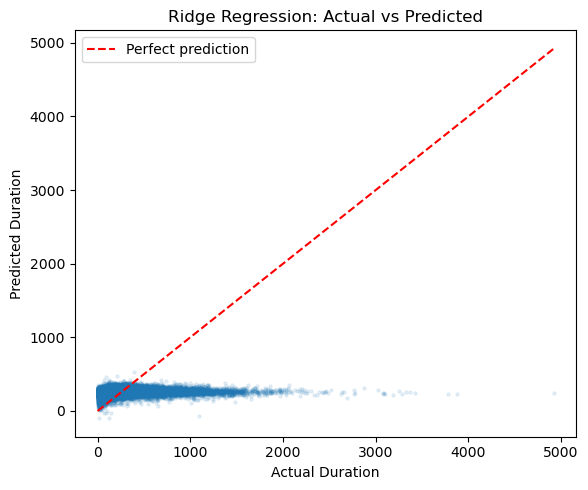

In [18]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

pipe_ridge = Pipeline([
    ('preprocessor', reg_preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

# Out-of-fold predictions using cross_val_predict
ridge_preds = cross_val_predict(pipe_ridge, X_reg, y_reg, cv=cv)
eval_regression("Ridge Regression (CV)", y_reg, ridge_preds)

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_reg, ridge_preds, alpha=0.1, s=5)
ax.plot([0, y_reg.max()], [0, y_reg.max()], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Duration')
ax.set_ylabel('Predicted Duration')
ax.set_title('Ridge Regression: Actual vs Predicted')
ax.legend()
plt.tight_layout()
plt.show()

## Section 3.3: Random Forest Regressor
I'm using Random Forest Regression to conduct a non-linear comparison. This method builds hundreds of decision trees and averages their forecasts. This is usually stronger than just one tree. The best part is that it can automatically detect interactions between features, such how older clients with bigger balances could have varied call lengths. I don't have to create those interaction terms by hand. Random forests also perform a good job with outliers and provide me feature importance scores so I can see what's behind the predictions.


=== Random Forest Regressor (CV) ===
  R²:   0.0186
  RMSE: 255.12
  MAE:  168.09


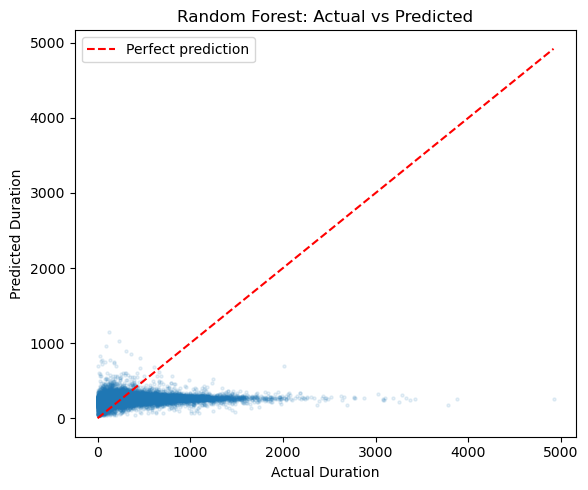

In [19]:
from sklearn.ensemble import RandomForestRegressor

pipe_rf = Pipeline([
    ('preprocessor', reg_preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=10,
                                         random_state=42, n_jobs=-1))
])

# Out of fold predictions
rf_preds = cross_val_predict(pipe_rf, X_reg, y_reg, cv=cv)
eval_regression("Random Forest Regressor (CV)", y_reg, rf_preds)

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_reg, rf_preds, alpha=0.1, s=5)
ax.plot([0, y_reg.max()], [0, y_reg.max()], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Duration')
ax.set_ylabel('Predicted Duration')
ax.set_title('Random Forest: Actual vs Predicted')
ax.legend()
plt.tight_layout()
plt.show()

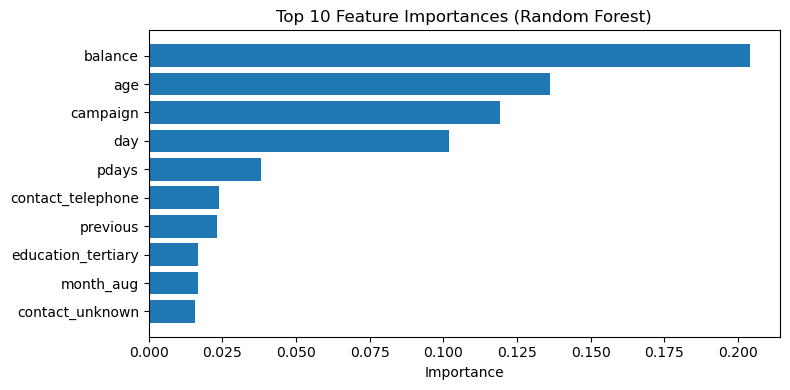

In [20]:
# Feature importances (Random Forest)
pipe_rf.fit(X_reg, y_reg)
feature_names = (reg_num +
                 pipe_rf.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .get_feature_names_out(reg_cat).tolist())
importances = pipe_rf.named_steps['regressor'].feature_importances_

top_n = 10
idx = np.argsort(importances)[-top_n:]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(np.array(feature_names)[idx], importances[idx])
ax.set_title('Top 10 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Section 3.4: Selection of Final Approach
The metrics table reveals that both models have relatively low R² values (Ridge: 0.016, Random Forest: 0.019), which means that neither of them explains more than 2% of the difference in call length. This is to be expected and not a flaw in the models. The length of a call is mostly determined by how the conversation is going in real time, including the client's questions, objections, degree of interest, and rapport with the agent. None of these things can be known before the call is made. The scatter plots back this up, showing that both models predict values that are close to the mean (around 259 seconds) no matter how long they really last.
Random Forest does a little better than Ridge on all measures (RMSE: 255.12 vs. 255.48; MAE: 168.09 vs. 168.43; R²: 0.019 vs. 0.016). This is probably because it can capture non-linear interactions that a linear model can't. The examination of feature importance backs this up: balance (20%), age (13%), and campaign (10%) are the most useful features. This makes sense because wealthier and older clients may talk for longer periods of time, while repeated contacts tend to abbreviate calls. So, Random Forest is the last regression model chosen.
Even if the R² is low, the expected length is nevertheless kept as a designed attribute for classification. Even a poor predictive signal (correlation with actual duration: 0.138) can add some value when combined with other data. Cross_val_predict uses out-of-fold forecasts instead of in-sample predictions. This makes sure that the projected duration for each row came from a model that never saw that row during training, which prevents data from leaking into the classification phase.

In [21]:
# Random Forest out of fold predictions
df['predicted_duration'] = rf_preds

print("predicted_duration added to dataframe.")
print(f"  Mean: {df['predicted_duration'].mean():.1f}")
print(f"  Std:  {df['predicted_duration'].std():.1f}")
print(f"  Correlation with actual duration: {df['duration'].corr(df['predicted_duration']):.4f}")

assert 'duration' not in reg_num + reg_cat, "Duration must not be in features!"
print("\nNo target leakage: actual duration excluded from features.")

predicted_duration added to dataframe.
  Mean: 258.7
  Std:  41.6
  Correlation with actual duration: 0.1383

No target leakage: actual duration excluded from features.



## Section 4: Classification

## Section 4.1: Classification Pipeline Setup and Leakage Verification


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Classification features: pre-call, cluster, predicted_duration (NO actual duration)
cls_num = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous',
           'was_previously_contacted', 'cluster', 'predicted_duration']
cls_cat = ['job', 'marital', 'education', 'default', 'housing',
           'loan', 'contact', 'month', 'poutcome']

X_cls = df[cls_num + cls_cat]
y_cls = df['y']

# Verify no leakage
assert 'duration' not in cls_num + cls_cat, "LEAKAGE: actual duration in features!"
print("No target leakage confirmed.")
print(f"Classification features: {len(cls_num)} numeric + {len(cls_cat)} categorical")

# Train-test split (stratified due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train target rate: {y_train.mean():.3f} | Test target rate: {y_test.mean():.3f}")

cls_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), cls_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='infrequent_if_exist'), cls_cat)
])

No target leakage confirmed.
Classification features: 9 numeric + 9 categorical
Train: 36168 | Test: 9043
Train target rate: 0.117 | Test target rate: 0.117


## Section 4.2: Logistic Regression
I used Logistic Regression(class_weight='balanced') as my linear baseline. Logistic Regression is a good first step for putting two things into groups. Setting class_weight='balanced' automatically provides more weight to the minority class (11.7% of subscribers), which is the reverse of how often the class occurs. This fixes the 7.5:1 imbalance without resampling. This makes the minority class more likely to be remembered, but it lowers accuracy. This is fine when making more calls is cheaper than missing out on possible subscribers.

=== Logistic Regression ===
AUC-ROC: 0.7746
              precision    recall  f1-score   support

          No       0.94      0.77      0.85      7985
         Yes       0.27      0.64      0.38      1058

    accuracy                           0.76      9043
   macro avg       0.61      0.71      0.61      9043
weighted avg       0.86      0.76      0.79      9043



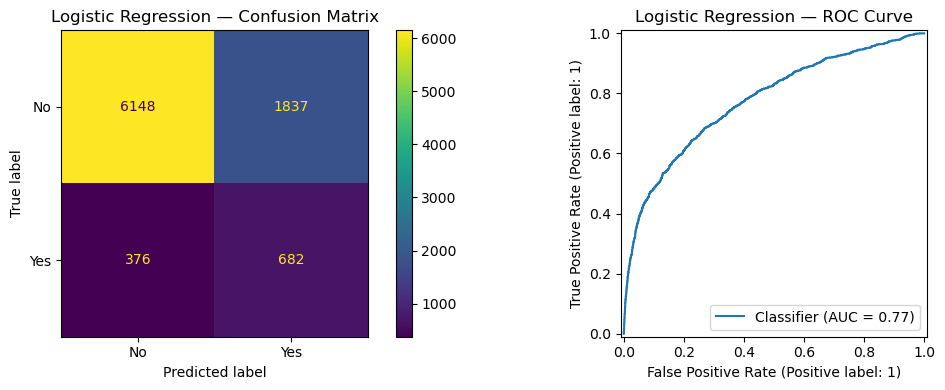

In [23]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('preprocessor', cls_preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)
lr_preds = pipe_lr.predict(X_test)
lr_probs = pipe_lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(f"AUC-ROC: {roc_auc_score(y_test, lr_probs):.4f}")
print(classification_report(y_test, lr_preds, target_names=['No', 'Yes']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, display_labels=['No', 'Yes'], ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix')
RocCurveDisplay.from_predictions(y_test, lr_probs, ax=axes[1])
axes[1].set_title('Logistic Regression — ROC Curve')
plt.tight_layout()
plt.show()

## Section 4.3: Gradient Boosting
I moved on to a Gradient Boosting Classifier to get around the problems with the linear baseline. Logistic Regression thinks that the relationship between variables is a straight line. Gradient Boosting, on the other hand, develops a series of decision trees, where each new tree fixes the mistakes caused by the prior ones.
This iterative process lets the model automatically find complicated, non-linear relationships, such how age might effect subscription rates differently based on income levels, without me having to manually add those features. I also used the scale_pos_weight parameter to directly counteract the dataset's skew, making sure the model stays sensitive to the minority class.

=== Gradient Boosting ===
AUC-ROC: 0.8009
              precision    recall  f1-score   support

          No       0.91      0.98      0.94      7985
         Yes       0.64      0.25      0.36      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.62      0.65      9043
weighted avg       0.88      0.90      0.88      9043



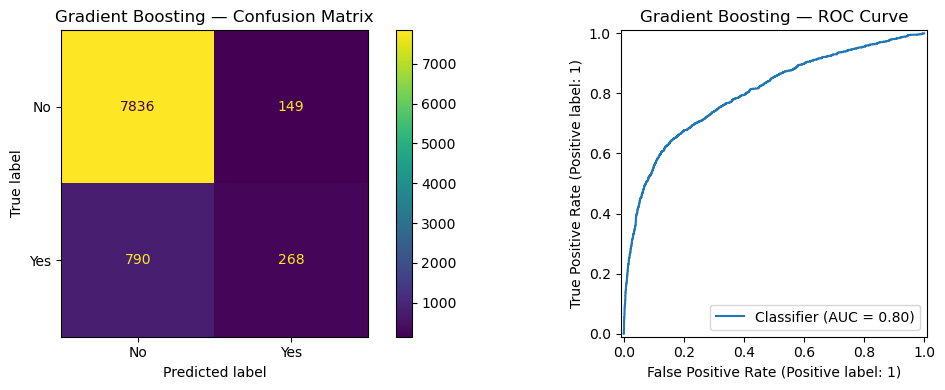

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

# Calculate scale_pos_weight equivalent
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

pipe_gb = Pipeline([
    ('preprocessor', cls_preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        random_state=42))
])

pipe_gb.fit(X_train, y_train)
gb_preds = pipe_gb.predict(X_test)
gb_probs = pipe_gb.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting ===")
print(f"AUC-ROC: {roc_auc_score(y_test, gb_probs):.4f}")
print(classification_report(y_test, gb_preds, target_names=['No', 'Yes']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, gb_preds, display_labels=['No', 'Yes'], ax=axes[0])
axes[0].set_title('Gradient Boosting — Confusion Matrix')
RocCurveDisplay.from_predictions(y_test, gb_probs, ax=axes[1])
axes[1].set_title('Gradient Boosting — ROC Curve')
plt.tight_layout()
plt.show()

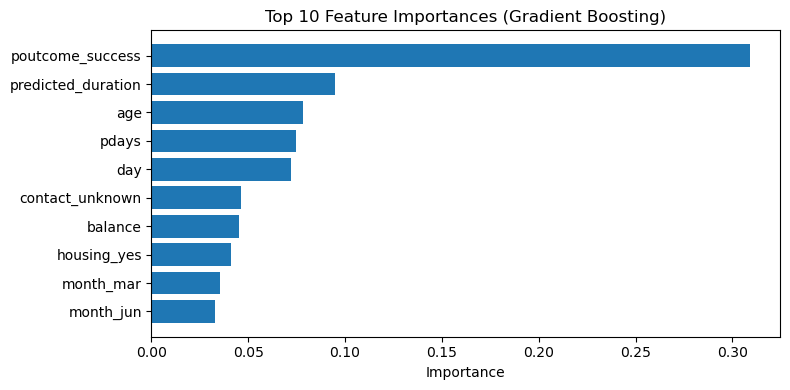

In [25]:
# Feature importances (Gradient Boosting)
feature_names_cls = (cls_num +
                     pipe_gb.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .get_feature_names_out(cls_cat).tolist())
importances_cls = pipe_gb.named_steps['classifier'].feature_importances_

top_n = 10
idx = np.argsort(importances_cls)[-top_n:]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(np.array(feature_names_cls)[idx], importances_cls[idx])
ax.set_title('Top 10 Feature Importances (Gradient Boosting)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Section 4.4: Selection of Final Approach
The table and ROC curves above make it easy to compare. Gradient Boosting has a higher AUC-ROC (0.801 vs. 0.775) and overall accuracy (90% vs. 76%), which means it can tell the difference between things better at all thresholds. But the class of interest is the minority class, which is subscribers. In this case, the two models show a real precision-recall tradeoff. Logistic Regression gets 64% of real subscribers (682 out of 1,058), but it also gets 1,837 false positives (27% accuracy). When it predicts "yes," Gradient Boosting is accurate (65% accuracy), yet it only finds 25% of subscribers, missing 790 out of 1,058. For the target application, which is a bank telemarketing campaign, remember is the most important thing. A missed subscriber means lost money on a term deposit, yet a false positive just costs one more phone call. Logistic Regression is the better model for practical use since it has a higher F1 score for the minority class (0.38 vs. 0.36) and a far greater recall rate (64% vs. 25%). It is chosen as the last way to classify. The Gradient Boosting feature importance analysis confirms the end-to-end pipeline: poutcome_success (31%) is the strongest predictor, and predicted_duration (10%), the engineered feature from Section 3, is the second strongest predictor. This shows that the regression step adds useful information to the classification model that goes beyond just using raw pre-call attributes.

                 Logistic Regression  Gradient Boosting
AUC-ROC                       0.7746             0.8009
F1 (Yes)                      0.3813             0.3634
Precision (Yes)               0.2707             0.6427
Recall (Yes)                  0.6446             0.2533
Accuracy                      0.7553             0.8962


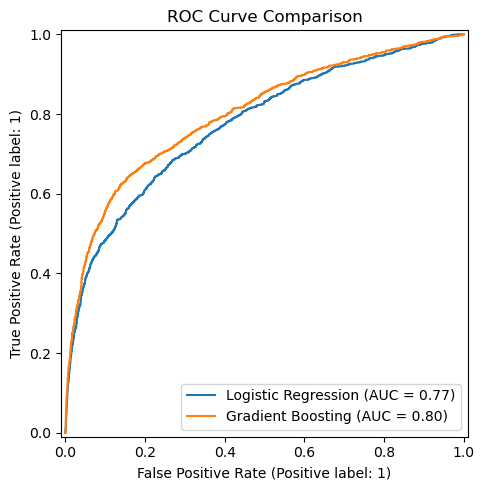

In [26]:
from sklearn.metrics import f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Logistic Regression': [
        roc_auc_score(y_test, lr_probs),
        f1_score(y_test, lr_preds),
        precision_score(y_test, lr_preds),
        recall_score(y_test, lr_preds),
        (lr_preds == y_test).mean()
    ],
    'Gradient Boosting': [
        roc_auc_score(y_test, gb_probs),
        f1_score(y_test, gb_preds),
        precision_score(y_test, gb_preds),
        recall_score(y_test, gb_preds),
        (gb_preds == y_test).mean()
    ]
}, index=['AUC-ROC', 'F1 (Yes)', 'Precision (Yes)', 'Recall (Yes)', 'Accuracy'])

print(results.round(4))

# Overlay ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, lr_probs, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, gb_probs, name='Gradient Boosting', ax=ax)
ax.set_title('ROC Curve Comparison')
plt.tight_layout()
plt.show()